In [7]:
import pandas as pd

# Trader data
df = pd.read_csv("historical_data.csv")

# Fear-Greed data
fear_df = pd.read_csv("fear_greed_index.csv")

In [8]:
df.head()
fear_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [11]:
fear_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [13]:
fear_df['date'] = pd.to_datetime(fear_df['date'], format='mixed', dayfirst=True)

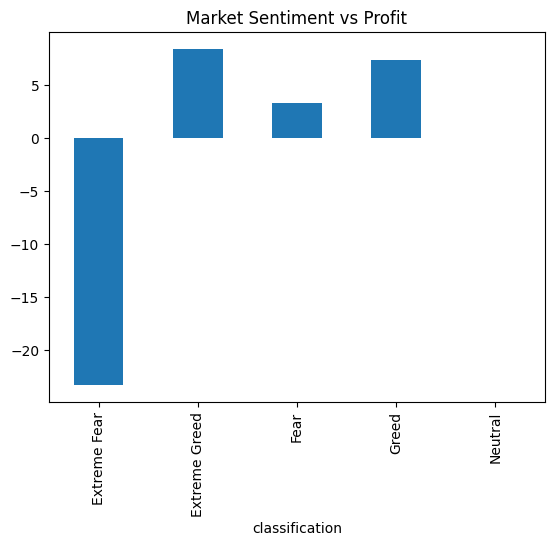

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("historical_data.csv")
fear_df = pd.read_csv("fear_greed_index.csv")

# Convert dates
df['Timestamp IST'] = pd.to_datetime(df['Timestamp IST'], dayfirst=True)
fear_df['date'] = pd.to_datetime(fear_df['date'], format='mixed', dayfirst=True)

# Merge
merged_df = pd.merge(df, fear_df, left_on='Timestamp IST', right_on='date', how='inner')

# Analysis
merged_df.groupby('classification')['Closed PnL'].mean()

# Graph
merged_df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Market Sentiment vs Profit")
plt.show()

In [15]:
merged_df.shape

(144, 20)

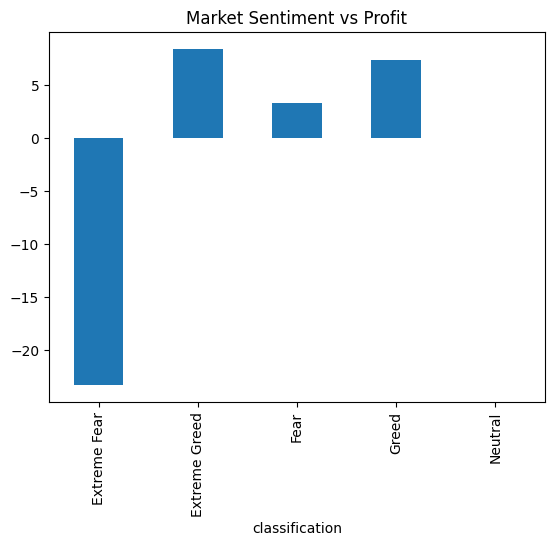

In [16]:
merged_df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Market Sentiment vs Profit")
plt.show()

In [17]:
merged_df.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear    -23.260258
Extreme Greed     8.401634
Fear              3.269807
Greed             7.398914
Neutral           0.000000
Name: Closed PnL, dtype: float64